# Career Atlas: Modeling, Clustering, and Dashboard Outputs

This notebook reads the cleaned 2020-2024 occupation–metro dataset created by the data-wrangling notebook and performs modeling tasks only.

Main outputs:

- Metro clustering with K-Means and PCA
- Nearest-neighbor metro similarity tables
- Occupation-specific career-city scores for dashboard ranking
- Forecasting models using time-based train/validation/test splits
- Dashboard-ready prediction tables

This notebook assumes the following file already exists:

- `data/processed/career_city_fit_2020_2024.csv`

## 1. Setup

In [4]:
%pip install -q polars pandas numpy matplotlib scikit-learn joblib pyarrow


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

from IPython.display import display

from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42

pl.Config.set_tbl_rows(12)
pl.Config.set_tbl_cols(16)
pl.Config.set_fmt_str_lengths(90)

PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELING_DIR = DATA_DIR / "modeling"
MODEL_DIR = MODELING_DIR / "models"
FIG_DIR = PROJECT_ROOT / "figures" / "modeling"

for path in [MODELING_DIR, MODEL_DIR, FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

FINAL_DATASET_CSV_PATH = PROCESSED_DIR / "career_city_fit_2020_2024.csv"
LATEST_SCORE_CSV_PATH = PROCESSED_DIR / "career_city_scores_latest.csv"
METRO_PROFILE_CSV_PATH = MODELING_DIR / "metro_profiles_clustered_latest.csv"
NEAREST_METROS_CSV_PATH = MODELING_DIR / "nearest_metros_latest.csv"
REGRESSION_METRICS_CSV_PATH = MODELING_DIR / "regression_model_metrics.csv"
REGRESSION_TEST_PREDICTIONS_CSV_PATH = MODELING_DIR / "regression_test_predictions.csv"
FUTURE_PREDICTIONS_CSV_PATH = PROCESSED_DIR / "career_city_next_year_predictions_latest.csv"
FINAL_DASHBOARD_OUTPUT_CSV_PATH = PROCESSED_DIR / "dashboard_modeling_output_latest.csv"

## 2. Helper Functions

In [6]:
def print_shape(label: str, df) -> None:
    if isinstance(df, pl.DataFrame):
        print(f"{label}: {df.height:,} rows × {df.width:,} columns")
    else:
        print(f"{label}: {df.shape[0]:,} rows × {df.shape[1]:,} columns")


def read_final_dataset(path: Path = FINAL_DATASET_CSV_PATH) -> pl.DataFrame:
    df = pl.read_csv(path, infer_schema_length=5000)

    if "cbsa_code" in df.columns:
        df = df.with_columns(
            pl.col("cbsa_code").cast(pl.Utf8).str.zfill(5).alias("cbsa_code")
        )

    if "occ_code" in df.columns:
        df = df.with_columns(
            pl.col("occ_code").cast(pl.Utf8).alias("occ_code")
        )

    if "year" in df.columns:
        df = df.with_columns(pl.col("year").cast(pl.Int64).alias("year"))

    return df


def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    return numerator / denominator.replace(0, np.nan)


def regression_metrics(y_true, y_pred) -> dict[str, float]:
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": r2_score(y_true, y_pred),
    }


def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def get_pipeline_feature_names(
    pipeline: Pipeline,
    numeric_features: list[str],
    categorical_features: list[str],
) -> list[str]:
    preprocessor = pipeline.named_steps["preprocess"]
    feature_names = []

    if "num" in preprocessor.named_transformers_:
        feature_names.extend(numeric_features)

    if "cat" in preprocessor.named_transformers_:
        cat_pipeline = preprocessor.named_transformers_["cat"]
        encoder = cat_pipeline.named_steps["onehot"]
        feature_names.extend(list(encoder.get_feature_names_out(categorical_features)))

    return feature_names


def save_json(obj: dict, path: Path) -> None:
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)

## 3. Load Processed Dataset

In [7]:
df_all = read_final_dataset()

print_shape("Loaded final processed dataset", df_all)

latest_year = df_all.select(pl.col("year").max()).item()
earliest_year = df_all.select(pl.col("year").min()).item()

print(f"Years available: {earliest_year}-{latest_year}")
display(df_all.head(10).to_pandas())

Loaded final processed dataset: 689,932 rows × 38 columns
Years available: 2020-2024


,year,cbsa_code,bls_msa_name,acs_area_name,prim_state,occ_code,occ_title,o_group,tot_emp,emp_prse,...,annual_mean_wage_to_metro_income_ratio,annual_median_wage_to_metro_income_ratio,log_tot_emp,low_employment_flag,high_lq_flag,has_valid_mean_affordability,has_valid_median_affordability,area_title,rent_to_annual_mean_wage_ratio,rent_to_annual_median_wage_ratio
0,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-1021,General and Operations Managers,detailed,1320.0,7.4,...,1.531072,1.249613,7.185387,False,False,True,True,"Abilene, TX",0.129730,0.158950
1,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-2022,Sales Managers,detailed,90.0,18.5,...,2.206099,1.986984,4.499810,True,False,True,True,"Abilene, TX",0.090035,0.099963
2,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-2030,Public Relations and Fundraising Managers,detailed,40.0,31.5,...,1.741619,1.374118,3.688879,True,False,True,True,"Abilene, TX",0.114046,0.144548
3,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-3010,Administrative Services and Facilities Managers,detailed,140.0,12.3,...,1.432816,1.329274,4.941642,False,False,True,True,"Abilene, TX",0.138626,0.149424
4,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-3021,Computer and Information Systems Managers,detailed,70.0,30.2,...,2.242923,2.133912,4.248495,True,False,True,True,"Abilene, TX",0.088557,0.093080
5,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-3031,Financial Managers,detailed,120.0,8.8,...,2.179849,1.751463,4.787492,False,False,True,True,"Abilene, TX",0.091119,0.113405
6,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-3051,Industrial Production Managers,detailed,50.0,22.3,...,2.072297,1.798859,3.912023,True,False,True,True,"Abilene, TX",0.095848,0.110418
7,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-3071,"Transportation, Storage, and Distribution Mana...",detailed,60.0,18.6,...,1.550030,1.502634,4.094345,True,False,True,True,"Abilene, TX",0.128143,0.132185
8,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-3121,Human Resources Managers,detailed,60.0,45.1,...,1.189274,0.887580,4.094345,True,False,True,True,"Abilene, TX",0.167014,0.223783
9,2020,10180,"Abilene, TX","Abilene, TX Metro Area",TX,11-9021,Construction Managers,detailed,160.0,14.2,...,1.402738,1.164300,5.075174,False,False,True,True,"Abilene, TX",0.141598,0.170597


In [9]:
year_summary = (
    df_all
    .group_by("year")
    .agg([
        pl.len().alias("n_rows"),
        pl.col("cbsa_code").n_unique().alias("n_metros"),
        pl.col("occ_code").n_unique().alias("n_occupations"),
        (pl.col("rent_to_median_wage_ratio").is_not_null().cast(pl.Float64).mean() * 100)
        .round(2)
        .alias("pct_valid_rent_burden"),
    ])
    .sort("year")
)

display(year_summary.to_pandas())

,year,n_rows,n_metros,n_occupations,pct_valid_rent_burden
0,2020,131010,396,785,91.26
1,2021,138116,396,826,92.24
2,2022,139124,396,828,92.45
3,2023,140518,396,826,91.29
4,2024,141164,393,823,98.33


## 4. Dashboard Ranking Score

The dashboard score is not a predictive model. It is a transparent ranking score for the latest available year.

For each occupation, metros are ranked against other metros for the same occupation.

Higher score is better.

Score components:

- Affordability: annual median wage divided by annual rent
- Wage: annual median wage
- Occupational concentration: location quotient
- Employment scale: log employment

In [10]:
latest = df_all.filter(pl.col("year") == latest_year).to_pandas()

score_required_cols = [
    "year",
    "cbsa_code",
    "bls_msa_name",
    "acs_area_name",
    "prim_state",
    "occ_code",
    "occ_title",
    "wage_annual_median",
    "annual_rent",
    "rent_to_median_wage_ratio",
    "median_wage_to_rent_ratio",
    "tot_emp",
    "jobs_1000",
    "loc_quotient",
]

score_df = latest[[c for c in score_required_cols if c in latest.columns]].copy()

score_df = score_df.dropna(
    subset=[
        "occ_code",
        "occ_title",
        "cbsa_code",
        "bls_msa_name",
        "wage_annual_median",
        "annual_rent",
        "rent_to_median_wage_ratio",
        "median_wage_to_rent_ratio",
    ]
)

score_df["tot_emp"] = score_df["tot_emp"].fillna(0)
score_df["loc_quotient"] = score_df["loc_quotient"].fillna(0)
score_df["jobs_1000"] = score_df["jobs_1000"].fillna(0)
score_df["log_tot_emp_for_score"] = np.log1p(score_df["tot_emp"].clip(lower=0))

score_components = {
    "affordability_component": "median_wage_to_rent_ratio",
    "wage_component": "wage_annual_median",
    "lq_component": "loc_quotient",
    "employment_component": "log_tot_emp_for_score",
}

for component_name, source_col in score_components.items():
    score_df[component_name] = (
        score_df
        .groupby("occ_code")[source_col]
        .rank(method="average", pct=True)
    )

score_df["career_city_score"] = (
    0.45 * score_df["affordability_component"]
    + 0.25 * score_df["wage_component"]
    + 0.20 * score_df["lq_component"]
    + 0.10 * score_df["employment_component"]
)

score_df["career_city_score_0_100"] = 100 * score_df["career_city_score"]
score_df["low_employment_warning"] = score_df["tot_emp"] < 100
score_df["low_lq_warning"] = score_df["loc_quotient"] < 0.75

score_df = score_df.sort_values(
    ["occ_title", "career_city_score_0_100"],
    ascending=[True, False],
)

score_df.to_csv(LATEST_SCORE_CSV_PATH, index=False)

print_shape("Latest-year dashboard score table", score_df)
print(f"Saved: {LATEST_SCORE_CSV_PATH}")

display(score_df.head(15))

Latest-year dashboard score table: 138,812 rows × 23 columns
Saved: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/processed/career_city_scores_latest.csv


,year,cbsa_code,bls_msa_name,acs_area_name,prim_state,occ_code,occ_title,wage_annual_median,annual_rent,rent_to_median_wage_ratio,...,loc_quotient,log_tot_emp_for_score,affordability_component,wage_component,lq_component,employment_component,career_city_score,career_city_score_0_100,low_employment_warning,low_lq_warning
122770,2024,44100,"Springfield, IL","Springfield, IL Metro Area",IL,13-2011,Accountants and Auditors,83970.0,11748,0.139907,...,1.64,7.365813,0.989822,0.895674,0.991094,0.702290,0.937786,93.778626,False,False
95144,2024,37620,"Parkersburg-Vienna, WV","Parkersburg-Vienna, WV Metro Area",WV,13-2011,Accountants and Auditors,95640.0,9816,0.102635,...,1.76,6.415097,1.000000,0.977099,1.000000,0.422392,0.936514,93.651399,False,False
80658,2024,33220,"Midland, MI","Midland, MI Metro Area",MI,13-2011,Accountants and Auditors,86390.0,12192,0.141127,...,1.48,6.274762,0.984733,0.923664,0.984733,0.361323,0.907125,90.712468,False,False
120860,2024,43620,"Sioux Falls, SD-MN","Sioux Falls, SD-MN Metro Area",SD,13-2011,Accountants and Auditors,79650.0,12264,0.153974,...,1.43,7.762596,0.918575,0.773537,0.975827,0.770992,0.879008,87.900763,False,False
18941,2024,15380,"Buffalo-Cheektowaga, NY","Buffalo-Cheektowaga, NY Metro Area",NY,13-2011,Accountants and Auditors,80240.0,12684,0.158076,...,1.03,8.543056,0.890585,0.798982,0.815522,0.877863,0.851399,85.139949,False,False
27094,2024,17410,"Cleveland, OH","Cleveland, OH Metro Area",OH,13-2011,Accountants and Auditors,78360.0,12600,0.160796,...,1.18,9.352794,0.832061,0.702290,0.914758,0.936387,0.826590,82.659033,False,False
33198,2024,19340,"Davenport-Moline-Rock Island, IA-IL","Davenport-Moline-Rock Island, IA-IL Metro Area",IA,13-2011,Accountants and Auditors,77280.0,11292,0.146118,...,0.96,7.396949,0.966921,0.622137,0.746819,0.704835,0.810496,81.049618,False,False
129310,2024,46140,"Tulsa, OK","Tulsa, OK Metro Area",OK,13-2011,Accountants and Auditors,78500.0,12936,0.164790,...,1.12,8.472405,0.783715,0.709924,0.874046,0.865140,0.791476,79.147583,False,False
125215,2024,45060,"Syracuse, NY","Syracuse, NY Metro Area",NY,13-2011,Accountants and Auditors,79790.0,12924,0.161975,...,0.94,7.867489,0.814249,0.781170,0.729008,0.795165,0.787023,78.702290,False,False
131175,2024,46540,"Utica-Rome, NY","Utica-Rome, NY Metro Area",NY,13-2011,Accountants and Auditors,76730.0,11100,0.144663,...,0.92,6.918695,0.969466,0.587786,0.707379,0.595420,0.784224,78.422392,False,False


In [11]:
example_occupation = None

for keyword in ["software developers", "registered nurses", "accountants", "data scientists"]:
    matches = score_df.loc[
        score_df["occ_title"].str.lower().str.contains(keyword, na=False),
        "occ_title",
    ].unique()

    if len(matches) > 0:
        example_occupation = matches[0]
        break

if example_occupation is None:
    example_occupation = score_df["occ_title"].value_counts().index[0]

print(f"Example occupation: {example_occupation}")

example_score_table = (
    score_df
    .loc[score_df["occ_title"] == example_occupation]
    .sort_values("career_city_score_0_100", ascending=False)
    .head(15)
    [
        [
            "bls_msa_name",
            "career_city_score_0_100",
            "wage_annual_median",
            "annual_rent",
            "rent_to_median_wage_ratio",
            "tot_emp",
            "loc_quotient",
            "low_employment_warning",
            "low_lq_warning",
        ]
    ]
)

display(example_score_table)

Example occupation: Software Developers


,bls_msa_name,career_city_score_0_100,wage_annual_median,annual_rent,rent_to_median_wage_ratio,tot_emp,loc_quotient,low_employment_warning,low_lq_warning
13453,"Binghamton, NY",91.541995,129600.0,11268,0.086944,1130.0,1.10,False,False
18965,"Buffalo-Cheektowaga, NY",87.952756,128780.0,12684,0.098494,3720.0,0.65,False,True
14867,"Bloomington, IL",85.964567,121590.0,12108,0.099581,1300.0,1.35,False,False
3894,"Ames, IA",85.485564,127040.0,12000,0.094458,440.0,0.73,False,True
97743,"Pittsburgh, PA",84.954068,122350.0,12636,0.103277,8820.0,0.74,False,True
98372,"Pittsfield, MA",83.753281,132760.0,13164,0.099156,310.0,0.51,False,True
35657,"Des Moines-West Des Moines, IA",82.217848,124630.0,13800,0.110728,4750.0,1.09,False,False
138722,"Winston-Salem, NC",82.007874,125140.0,12192,0.097427,1270.0,0.43,False,True
125238,"Syracuse, NY",81.443570,121340.0,12924,0.106511,2140.0,0.68,False,True
2091,"Albuquerque, NM",79.908136,125450.0,13872,0.110578,2830.0,0.66,False,True


## 5. Metro Profiles for Clustering

This section aggregates the latest-year occupation–metro data into one row per metro.

The goal is not to predict an outcome. The goal is to create metro-level segments and similarity features that are useful for the dashboard.

In [12]:
latest_pd = df_all.filter(pl.col("year") == latest_year).to_pandas()

latest_pd["occ_major"] = latest_pd["occ_code"].astype(str).str.slice(0, 2)

metro_profile = (
    latest_pd
    .groupby(["cbsa_code", "bls_msa_name", "prim_state"], dropna=False)
    .agg(
        annual_rent=("annual_rent", "median"),
        median_gross_rent=("median_gross_rent", "median"),
        median_household_income=("median_household_income", "median"),
        population=("population", "median"),
        mean_occ_wage=("wage_annual_median", "mean"),
        median_occ_wage=("wage_annual_median", "median"),
        std_occ_wage=("wage_annual_median", "std"),
        mean_rent_burden=("rent_to_median_wage_ratio", "mean"),
        median_rent_burden=("rent_to_median_wage_ratio", "median"),
        mean_wage_to_rent=("median_wage_to_rent_ratio", "mean"),
        mean_loc_quotient=("loc_quotient", "mean"),
        median_loc_quotient=("loc_quotient", "median"),
        share_high_lq=("high_lq_flag", "mean"),
        mean_jobs_1000=("jobs_1000", "mean"),
        occupation_rows=("occ_code", "nunique"),
        metro_occ_emp_sum=("tot_emp", "sum"),
    )
    .reset_index()
)

mix_base = latest_pd.dropna(subset=["cbsa_code", "occ_major", "tot_emp"]).copy()
mix_base["tot_emp"] = mix_base["tot_emp"].clip(lower=0)

occ_mix = (
    mix_base
    .groupby(["cbsa_code", "occ_major"])["tot_emp"]
    .sum()
    .unstack(fill_value=0)
)

occ_mix = occ_mix.div(occ_mix.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)
occ_mix.columns = [f"emp_share_soc_{c}" for c in occ_mix.columns]
occ_mix = occ_mix.reset_index()

metro_profile = metro_profile.merge(occ_mix, on="cbsa_code", how="left")

for col in occ_mix.columns:
    if col != "cbsa_code":
        metro_profile[col] = metro_profile[col].fillna(0)

metro_profile["log_population"] = np.log1p(metro_profile["population"].clip(lower=0))
metro_profile["log_metro_occ_emp_sum"] = np.log1p(metro_profile["metro_occ_emp_sum"].clip(lower=0))

print_shape("Metro profile table", metro_profile)
display(metro_profile.head())

Metro profile table: 393 rows × 43 columns


,cbsa_code,bls_msa_name,prim_state,annual_rent,median_gross_rent,median_household_income,population,mean_occ_wage,median_occ_wage,std_occ_wage,...,emp_share_soc_39,emp_share_soc_41,emp_share_soc_43,emp_share_soc_45,emp_share_soc_47,emp_share_soc_49,emp_share_soc_51,emp_share_soc_53,log_population,log_metro_occ_emp_sum
0,10180,"Abilene, TX",TX,13692.0,1141.0,67328.0,180408.0,55135.689655,48405.0,25675.380013,...,0.014372,0.098402,0.147089,0.000000,0.043555,0.052207,0.032703,0.078897,12.102982,11.130068
1,10380,"Aguadilla, PR",PR,6336.0,528.0,22398.0,251769.0,36581.406250,26420.0,22247.060506,...,0.005108,0.144880,0.151614,0.000000,0.043418,0.035988,0.099373,0.074298,12.436271,10.670605
2,10420,"Akron, OH",OH,12396.0,1033.0,72371.0,699820.0,61104.773784,54900.0,27319.724709,...,0.017095,0.086052,0.115162,0.000351,0.031187,0.038760,0.074645,0.104745,13.458580,12.653802
3,10500,"Albany, GA",GA,11400.0,950.0,56906.0,146018.0,55591.737288,47605.0,29142.549268,...,0.017155,0.111025,0.138782,0.000771,0.034117,0.055320,0.028913,0.111218,11.891492,10.856708
4,10540,"Albany, OR",OR,15840.0,1320.0,76329.0,130706.0,62273.138075,56270.0,26208.377850,...,0.037323,0.084101,0.121672,0.012192,0.053994,0.045534,0.096293,0.123165,11.780713,10.601398


## 6. K-Means Clustering and PCA Visualization

In [13]:
base_cluster_features = [
    "annual_rent",
    "median_household_income",
    "log_population",
    "mean_occ_wage",
    "median_occ_wage",
    "std_occ_wage",
    "mean_rent_burden",
    "median_rent_burden",
    "mean_wage_to_rent",
    "mean_loc_quotient",
    "median_loc_quotient",
    "share_high_lq",
    "mean_jobs_1000",
    "occupation_rows",
    "log_metro_occ_emp_sum",
]

mix_features = [c for c in metro_profile.columns if c.startswith("emp_share_soc_")]

cluster_features = base_cluster_features + mix_features

X_cluster = metro_profile[cluster_features].replace([np.inf, -np.inf], np.nan)

cluster_preprocess = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

X_cluster_scaled = cluster_preprocess.fit_transform(X_cluster)

k_results = []

for k in range(3, 9):
    if k >= len(metro_profile):
        continue

    kmeans_candidate = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=30,
    )

    labels = kmeans_candidate.fit_predict(X_cluster_scaled)

    k_results.append({
        "k": k,
        "inertia": kmeans_candidate.inertia_,
        "silhouette": silhouette_score(X_cluster_scaled, labels),
    })

k_results_df = pd.DataFrame(k_results).sort_values("k")
display(k_results_df)

best_k = int(k_results_df.sort_values("silhouette", ascending=False).iloc[0]["k"])

print(f"Selected k based on highest silhouette score: {best_k}")

,k,inertia,silhouette
0,3,10794.577838,0.115639
1,4,10121.711467,0.116534
2,5,9605.760416,0.097757
3,6,9170.553886,0.098682
4,7,8754.188687,0.095364
5,8,8449.880044,0.107894


Selected k based on highest silhouette score: 4


In [14]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=50,
)

metro_profile["metro_cluster"] = kmeans.fit_predict(X_cluster_scaled) + 1

pca = PCA(n_components=2, random_state=RANDOM_STATE)
metro_pca = pca.fit_transform(X_cluster_scaled)

metro_profile["pca_1"] = metro_pca[:, 0]
metro_profile["pca_2"] = metro_pca[:, 1]

explained_variance = pca.explained_variance_ratio_

print(f"PC1 explained variance: {explained_variance[0]:.2%}")
print(f"PC2 explained variance: {explained_variance[1]:.2%}")
print(f"Total explained variance: {explained_variance.sum():.2%}")

metro_profile.to_csv(METRO_PROFILE_CSV_PATH, index=False)

joblib.dump(
    {
        "preprocess": cluster_preprocess,
        "kmeans": kmeans,
        "pca": pca,
        "features": cluster_features,
        "latest_year": latest_year,
    },
    MODEL_DIR / "metro_clustering_pipeline.joblib",
)

print(f"Saved clustered metro profiles: {METRO_PROFILE_CSV_PATH}")
print(f"Saved clustering pipeline: {MODEL_DIR / 'metro_clustering_pipeline.joblib'}")

display(
    metro_profile
    .sort_values(["metro_cluster", "bls_msa_name"])
    .head(20)
)

PC1 explained variance: 31.17%
PC2 explained variance: 11.57%
Total explained variance: 42.74%
Saved clustered metro profiles: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/modeling/metro_profiles_clustered_latest.csv
Saved clustering pipeline: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/modeling/models/metro_clustering_pipeline.joblib


,cbsa_code,bls_msa_name,prim_state,annual_rent,median_gross_rent,median_household_income,population,mean_occ_wage,median_occ_wage,std_occ_wage,...,emp_share_soc_45,emp_share_soc_47,emp_share_soc_49,emp_share_soc_51,emp_share_soc_53,log_population,log_metro_occ_emp_sum,metro_cluster,pca_1,pca_2
4,10540,"Albany, OR",OR,15840.0,1320.0,76329.0,130706.0,62273.138075,56270.0,26208.377850,...,0.012192,0.053994,0.045534,0.096293,0.123165,11.780713,10.601398,1,-1.571754,0.661247
12,11200,"Amherst Town-Northampton, MA",MA,16656.0,1388.0,87001.0,162028.0,73687.342657,67905.0,30283.847769,...,0.000800,0.029285,0.032165,0.023204,0.049128,11.995531,11.042778,1,1.892948,1.065460
13,11260,"Anchorage, AK",AK,17496.0,1458.0,100505.0,401964.0,71967.732697,64380.0,32007.178589,...,0.000420,0.054483,0.051786,0.017262,0.099317,12.904120,12.024797,1,2.347743,1.130200
18,11700,"Asheville, NC",NC,15552.0,1296.0,71838.0,414711.0,59702.635294,50760.0,27808.563889,...,0.001169,0.038813,0.038813,0.061477,0.086424,12.935340,12.098382,1,0.541519,1.071102
21,12100,"Atlantic City-Hammonton, NJ",NJ,16476.0,1373.0,82105.0,371211.0,65703.064935,59730.0,30166.832452,...,0.001122,0.041259,0.034777,0.016142,0.063571,12.824529,11.985744,1,1.170512,4.264177
28,12700,"Barnstable Town, MA",MA,20136.0,1678.0,95241.0,231668.0,71636.939502,64260.0,29253.699520,...,0.001041,0.053691,0.035177,0.012960,0.066651,12.353065,11.366986,1,1.248158,4.428705
34,13380,"Bellingham, WA",WA,18660.0,1555.0,81784.0,230503.0,70701.385542,61850.0,30479.686364,...,0.002716,0.063290,0.038966,0.064588,0.074389,12.348023,11.346765,1,1.133751,1.426732
35,13460,"Bend, OR",OR,20364.0,1697.0,89788.0,257814.0,66307.306101,58500.0,28713.360242,...,0.002848,0.056756,0.038197,0.049980,0.076787,12.459998,11.531168,1,2.160955,3.175235
36,13740,"Billings, MT",MT,13404.0,1117.0,77194.0,189255.0,61267.008798,54520.0,27804.233118,...,0.001499,0.058240,0.050052,0.034252,0.094222,12.150856,11.370336,1,-0.851794,1.100061
39,13900,"Bismarck, ND",ND,12252.0,1021.0,85156.0,136216.0,64057.580071,59950.0,27105.412279,...,0.001867,0.052582,0.040604,0.032825,0.075296,11.822004,11.071019,1,-0.423645,0.476237


In [15]:
cluster_summary = (
    metro_profile
    .groupby("metro_cluster")
    .agg(
        n_metros=("cbsa_code", "count"),
        median_annual_rent=("annual_rent", "median"),
        median_household_income=("median_household_income", "median"),
        mean_occ_wage=("mean_occ_wage", "mean"),
        mean_rent_burden=("mean_rent_burden", "mean"),
        median_rent_burden=("median_rent_burden", "median"),
        mean_lq=("mean_loc_quotient", "mean"),
        share_high_lq=("share_high_lq", "mean"),
        median_population=("population", "median"),
    )
    .reset_index()
    .sort_values("metro_cluster")
)

cluster_summary_path = MODELING_DIR / "metro_cluster_summary.csv"
cluster_summary.to_csv(cluster_summary_path, index=False)

print(f"Saved cluster summary: {cluster_summary_path}")
display(cluster_summary)

Saved cluster summary: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/modeling/metro_cluster_summary.csv


,metro_cluster,n_metros,median_annual_rent,median_household_income,mean_occ_wage,mean_rent_burden,median_rent_burden,mean_lq,share_high_lq,median_population
0,1,65,16380.0,77194.0,62204.993784,0.318969,0.301800,1.497126,0.381236,187604.0
1,2,74,19350.0,93320.5,69462.650790,0.343726,0.327343,1.209395,0.285256,1214491.0
2,3,151,12948.0,71213.0,60691.369990,0.258419,0.245086,1.317981,0.296903,344337.0
3,4,103,11580.0,63328.0,54868.053154,0.251900,0.240882,1.577761,0.380137,126822.0


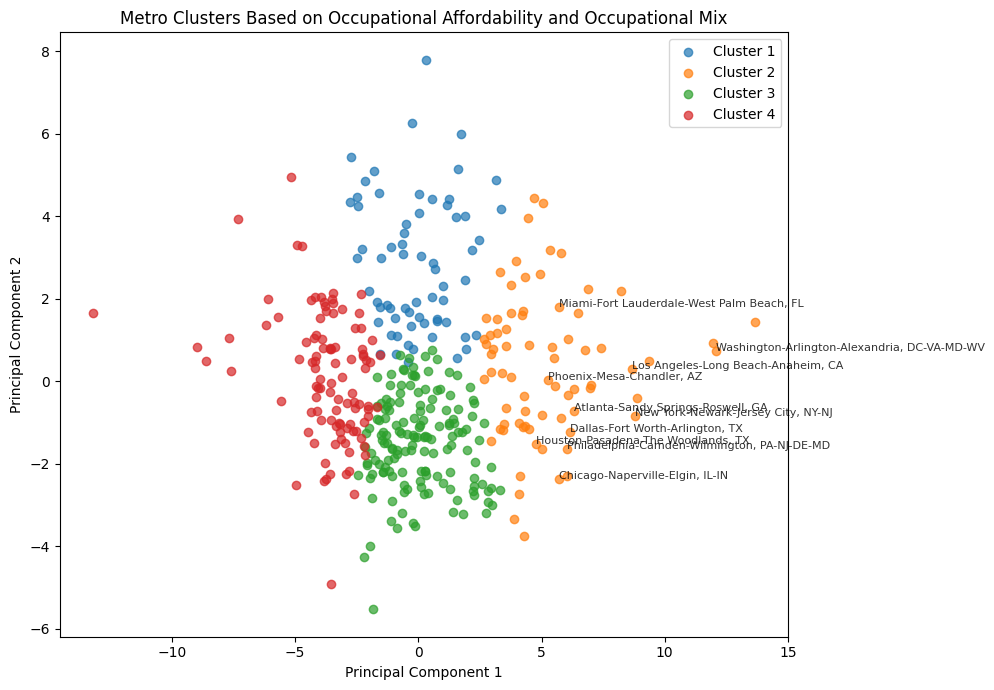

In [16]:
plt.figure(figsize=(10, 7))
for cluster_id, group in metro_profile.groupby("metro_cluster"):
    plt.scatter(
        group["pca_1"],
        group["pca_2"],
        alpha=0.7,
        label=f"Cluster {cluster_id}",
    )

largest_metros = metro_profile.sort_values("population", ascending=False).head(10)

for _, row in largest_metros.iterrows():
    plt.annotate(
        row["bls_msa_name"],
        (row["pca_1"], row["pca_2"]),
        fontsize=8,
        alpha=0.8,
    )

plt.title("Metro Clusters Based on Occupational Affordability and Occupational Mix")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "01_metro_clusters_pca.png", dpi=150)
plt.show()

## 7. Nearest-Neighbor Metro Similarity

This creates dashboard-ready nearest-neighbor recommendations.

For each metro, the table returns the most similar metros based on the same standardized features used for clustering.

In [17]:
N_NEIGHBORS = 10

nn = NearestNeighbors(
    n_neighbors=min(N_NEIGHBORS + 1, len(metro_profile)),
    metric="euclidean",
)

nn.fit(X_cluster_scaled)

distances, indices = nn.kneighbors(X_cluster_scaled)

metro_profile_reset = metro_profile.reset_index(drop=True)

nearest_rows = []

for source_pos in range(len(metro_profile_reset)):
    source_row = metro_profile_reset.iloc[source_pos]

    for rank in range(1, indices.shape[1]):
        neighbor_pos = indices[source_pos, rank]
        neighbor_row = metro_profile_reset.iloc[neighbor_pos]

        nearest_rows.append({
            "source_cbsa_code": source_row["cbsa_code"],
            "source_metro": source_row["bls_msa_name"],
            "source_cluster": source_row["metro_cluster"],
            "neighbor_rank": rank,
            "neighbor_cbsa_code": neighbor_row["cbsa_code"],
            "neighbor_metro": neighbor_row["bls_msa_name"],
            "neighbor_cluster": neighbor_row["metro_cluster"],
            "distance": distances[source_pos, rank],
            "neighbor_annual_rent": neighbor_row["annual_rent"],
            "neighbor_median_household_income": neighbor_row["median_household_income"],
            "neighbor_mean_occ_wage": neighbor_row["mean_occ_wage"],
            "neighbor_mean_rent_burden": neighbor_row["mean_rent_burden"],
            "neighbor_share_high_lq": neighbor_row["share_high_lq"],
        })

nearest_metros = pd.DataFrame(nearest_rows)
nearest_metros.to_csv(NEAREST_METROS_CSV_PATH, index=False)

joblib.dump(
    {
        "nearest_neighbors": nn,
        "metro_profile": metro_profile_reset,
        "features": cluster_features,
        "latest_year": latest_year,
    },
    MODEL_DIR / "nearest_neighbor_metro_model.joblib",
)

print_shape("Nearest-neighbor metro table", nearest_metros)
print(f"Saved: {NEAREST_METROS_CSV_PATH}")

display(nearest_metros.head(20))

Nearest-neighbor metro table: 3,930 rows × 13 columns
Saved: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/modeling/nearest_metros_latest.csv


,source_cbsa_code,source_metro,source_cluster,neighbor_rank,neighbor_cbsa_code,neighbor_metro,neighbor_cluster,distance,neighbor_annual_rent,neighbor_median_household_income,neighbor_mean_occ_wage,neighbor_mean_rent_burden,neighbor_share_high_lq
0,10180,"Abilene, TX",4,1,41660,"San Angelo, TX",4,2.139745,13860.0,68419.0,53710.088496,0.308914,0.339207
1,10180,"Abilene, TX",4,2,31180,"Lubbock, TX",3,3.045727,13908.0,63629.0,55197.615385,0.302625,0.279487
2,10180,"Abilene, TX",4,3,11100,"Amarillo, TX",3,3.158177,13032.0,69611.0,56042.767857,0.280383,0.276786
3,10180,"Abilene, TX",4,4,41540,"Salisbury, MD",1,3.223472,15288.0,73802.0,61384.125000,0.297659,0.398340
4,10180,"Abilene, TX",4,5,48660,"Wichita Falls, TX",4,3.250174,11940.0,65379.0,53743.181818,0.268036,0.337449
5,10180,"Abilene, TX",4,6,17300,"Clarksville, TN-KY",3,3.342791,14484.0,68967.0,56452.866667,0.305392,0.336634
6,10180,"Abilene, TX",4,7,43340,"Shreveport-Bossier City, LA",4,3.670122,12168.0,55925.0,53805.835777,0.277967,0.388406
7,10180,"Abilene, TX",4,8,47380,"Waco, TX",3,3.685019,13812.0,66205.0,58557.780980,0.285156,0.262108
8,10180,"Abilene, TX",4,9,45900,"Traverse City, MI",1,3.741214,14700.0,80889.0,59613.369565,0.282706,0.397112
9,10180,"Abilene, TX",4,10,47020,"Victoria, TX",4,3.801182,13812.0,70236.0,54239.476440,0.304401,0.402062


In [18]:
example_source_metro = metro_profile.sort_values("population", ascending=False).iloc[0]["bls_msa_name"]

print(f"Example source metro: {example_source_metro}")

display(
    nearest_metros
    .loc[nearest_metros["source_metro"] == example_source_metro]
    .sort_values("neighbor_rank")
)

Example source metro: New York-Newark-Jersey City, NY-NJ


,source_cbsa_code,source_metro,source_cluster,neighbor_rank,neighbor_cbsa_code,neighbor_metro,neighbor_cluster,distance,neighbor_annual_rent,neighbor_median_household_income,neighbor_mean_occ_wage,neighbor_mean_rent_burden,neighbor_share_high_lq
2530,35620,"New York-Newark-Jersey City, NY-NJ",2,1,31080,"Los Angeles-Long Beach-Anaheim, CA",2,4.107030,24756.0,95958.0,75985.213605,0.391403,0.267882
2531,35620,"New York-Newark-Jersey City, NY-NJ",2,2,37980,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD",2,4.984774,17760.0,91289.0,68677.914846,0.305247,0.202201
2532,35620,"New York-Newark-Jersey City, NY-NJ",2,3,40900,"Sacramento-Roseville-Folsom, CA",2,4.995896,21828.0,97188.0,77105.673457,0.340142,0.252322
2533,35620,"New York-Newark-Jersey City, NY-NJ",2,4,16980,"Chicago-Naperville-Elgin, IL-IN",2,5.522588,17160.0,90887.0,69881.547234,0.289628,0.192475
2534,35620,"New York-Newark-Jersey City, NY-NJ",2,5,33460,"Minneapolis-St. Paul-Bloomington, MN-WI",2,5.556065,17280.0,99833.0,72970.888084,0.277494,0.199695
2535,35620,"New York-Newark-Jersey City, NY-NJ",2,6,12580,"Baltimore-Columbia-Towson, MD",2,5.684252,19332.0,99470.0,70328.936794,0.328441,0.306709
2536,35620,"New York-Newark-Jersey City, NY-NJ",2,7,42660,"Seattle-Tacoma-Bellevue, WA",2,5.884567,24000.0,115177.0,81354.293333,0.346299,0.272861
2537,35620,"New York-Newark-Jersey City, NY-NJ",2,8,14460,"Boston-Cambridge-Newton, MA-NH",2,6.150003,24276.0,115863.0,77094.625835,0.374282,0.292868
2538,35620,"New York-Newark-Jersey City, NY-NJ",2,9,38900,"Portland-Vancouver-Hillsboro, OR-WA",2,6.199237,20688.0,97436.0,73340.863063,0.326810,0.306306
2539,35620,"New York-Newark-Jersey City, NY-NJ",2,10,41740,"San Diego-Chula Vista-Carlsbad, CA",2,6.333399,26952.0,106268.0,75658.287195,0.427138,0.285276


## 8. Build Supervised Forecasting Dataset

The supervised model predicts the current year's rent burden using only prior-year features.

For a row with target year `t`, features come from year `t-1`.

Target:

- `rent_to_median_wage_ratio` in target year `t`

Core baseline:

- persistence baseline: predict target year `t` using the prior year's rent burden ratio

In [19]:
panel = df_all.to_pandas()

panel["cbsa_code"] = panel["cbsa_code"].astype(str).str.zfill(5)
panel["occ_code"] = panel["occ_code"].astype(str)
panel["occ_major"] = panel["occ_code"].str.slice(0, 2)

panel = panel.sort_values(["cbsa_code", "occ_code", "year"]).reset_index(drop=True)

panel_keys = ["cbsa_code", "occ_code"]

lag_source_cols = [
    "rent_to_median_wage_ratio",
    "median_wage_to_rent_ratio",
    "wage_annual_median",
    "wage_annual_mean",
    "annual_rent",
    "median_household_income",
    "population",
    "tot_emp",
    "jobs_1000",
    "loc_quotient",
    "log_tot_emp",
]

for col in lag_source_cols:
    if col in panel.columns:
        panel[f"{col}_lag1"] = panel.groupby(panel_keys)[col].shift(1)
        panel[f"{col}_lag2"] = panel.groupby(panel_keys)[col].shift(2)

panel["rent_burden_change_lag1"] = (
    panel["rent_to_median_wage_ratio_lag1"]
    - panel["rent_to_median_wage_ratio_lag2"]
)

panel["wage_growth_lag1"] = safe_divide(
    panel["wage_annual_median_lag1"],
    panel["wage_annual_median_lag2"],
) - 1

panel["rent_growth_lag1"] = safe_divide(
    panel["annual_rent_lag1"],
    panel["annual_rent_lag2"],
) - 1

panel["employment_growth_lag1"] = safe_divide(
    panel["tot_emp_lag1"],
    panel["tot_emp_lag2"],
) - 1

panel["lq_change_lag1"] = (
    panel["loc_quotient_lag1"]
    - panel["loc_quotient_lag2"]
)

target_col = "rent_to_median_wage_ratio"
target_name = "target_rent_to_median_wage_ratio"

panel[target_name] = panel[target_col]
panel["target_year"] = panel["year"]

model_df = panel.dropna(
    subset=[
        target_name,
        "rent_to_median_wage_ratio_lag1",
        "wage_annual_median_lag1",
        "annual_rent_lag1",
    ]
).copy()

model_df = model_df.replace([np.inf, -np.inf], np.nan)

print_shape("Supervised modeling dataset", model_df)

display(
    model_df[
        [
            "target_year",
            "cbsa_code",
            "bls_msa_name",
            "occ_code",
            "occ_title",
            target_name,
            "rent_to_median_wage_ratio_lag1",
            "wage_annual_median_lag1",
            "annual_rent_lag1",
        ]
    ].head()
)

Supervised modeling dataset: 470,652 rows × 68 columns


,target_year,cbsa_code,bls_msa_name,occ_code,occ_title,target_rent_to_median_wage_ratio,rent_to_median_wage_ratio_lag1,wage_annual_median_lag1,annual_rent_lag1
1,2024,10180,"Abilene, TX",11-1011,Chief Executives,0.077129,0.064940,202340.0,13140.0
3,2021,10180,"Abilene, TX",11-1021,General and Operations Managers,0.153332,0.158950,68550.0,10896.0
4,2022,10180,"Abilene, TX",11-1021,General and Operations Managers,0.172319,0.153332,74270.0,11388.0
5,2023,10180,"Abilene, TX",11-1021,General and Operations Managers,0.169855,0.172319,73120.0,12600.0
6,2024,10180,"Abilene, TX",11-1021,General and Operations Managers,0.177036,0.169855,77360.0,13140.0


## 9. Time-Based Train / Validation / Test Split

Because this is a forecasting problem, rows are split by year rather than randomly.

With 2020-2024 data, the intended split is:

- Train: 2021-2022 target years
- Validation: 2023 target year
- Test: 2024 target year

In [21]:
available_target_years = sorted(model_df["target_year"].dropna().unique())

if len(available_target_years) >= 4:
    test_year = available_target_years[-1]
    val_year = available_target_years[-2]
    train_years = available_target_years[:-2]
elif len(available_target_years) == 3:
    test_year = available_target_years[-1]
    val_year = available_target_years[-2]
    train_years = available_target_years[:-2]
else:
    test_year = available_target_years[-1]
    val_year = None
    train_years = available_target_years[:-1]

train_df = model_df[model_df["target_year"].isin(train_years)].copy()

if val_year is not None:
    val_df = model_df[model_df["target_year"] == val_year].copy()
else:
    val_df = pd.DataFrame(columns=model_df.columns)

test_df = model_df[model_df["target_year"] == test_year].copy()

print(f"Available target years: {available_target_years}")
print(f"Train years: {train_years}")
print(f"Validation year: {val_year}")
print(f"Test year: {test_year}")

print_shape("Train", train_df)
print_shape("Validation", val_df)
print_shape("Test", test_df)

Available target years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Train years: [np.int64(2021), np.int64(2022)]
Validation year: 2023
Test year: 2024
Train: 225,114 rows × 68 columns
Validation: 122,718 rows × 68 columns
Test: 122,820 rows × 68 columns


## 10. Regression Features and Preprocessing

In [22]:
numeric_features = [
    "rent_to_median_wage_ratio_lag1",
    "median_wage_to_rent_ratio_lag1",
    "wage_annual_median_lag1",
    "wage_annual_mean_lag1",
    "annual_rent_lag1",
    "median_household_income_lag1",
    "population_lag1",
    "tot_emp_lag1",
    "jobs_1000_lag1",
    "loc_quotient_lag1",
    "log_tot_emp_lag1",
    "rent_burden_change_lag1",
    "wage_growth_lag1",
    "rent_growth_lag1",
    "employment_growth_lag1",
    "lq_change_lag1",
]

numeric_features = [c for c in numeric_features if c in model_df.columns]

categorical_features = [
    "occ_major",
    "prim_state",
]

categorical_features = [c for c in categorical_features if c in model_df.columns]

feature_cols = numeric_features + categorical_features

X_train = train_df[feature_cols]
y_train = train_df[target_name]

X_val = val_df[feature_cols] if len(val_df) > 0 else None
y_val = val_df[target_name] if len(val_df) > 0 else None

X_test = test_df[feature_cols]
y_test = test_df[target_name]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['rent_to_median_wage_ratio_lag1', 'median_wage_to_rent_ratio_lag1', 'wage_annual_median_lag1', 'wage_annual_mean_lag1', 'annual_rent_lag1', 'median_household_income_lag1', 'population_lag1', 'tot_emp_lag1', 'jobs_1000_lag1', 'loc_quotient_lag1', 'log_tot_emp_lag1', 'rent_burden_change_lag1', 'wage_growth_lag1', 'rent_growth_lag1', 'employment_growth_lag1', 'lq_change_lag1']

Categorical features:
['occ_major', 'prim_state']


In [24]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", make_one_hot_encoder()),
                ]
            ),
            categorical_features,
        ),
    ],
    remainder="drop",
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", make_one_hot_encoder()),
                ]
            ),
            categorical_features,
        ),
    ],
    remainder="drop",
)

model_specs = {
    "Linear Regression": Pipeline(
        steps=[
            ("preprocess", linear_preprocessor),
            ("model", LinearRegression()),
        ]
    ),
    "Ridge Regression": Pipeline(
        steps=[
            ("preprocess", clone(linear_preprocessor)),
            ("model", Ridge(alpha=1.0)),
        ]
    ),
    "Random Forest": Pipeline(
        steps=[
            ("preprocess", tree_preprocessor),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=150,
                    max_depth=16,
                    min_samples_leaf=20,
                    max_samples=0.75,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    ),
}

## 11. Baseline Models

In [25]:
def evaluate_prediction_rows(
    rows: list[dict],
    model_name: str,
    split_name: str,
    y_true,
    y_pred,
) -> None:
    metrics = regression_metrics(y_true, y_pred)
    rows.append({
        "model": model_name,
        "split": split_name,
        **metrics,
    })


metrics_rows = []

# Baseline 1: persistence, predicting this year's rent burden from last year's rent burden.
evaluate_prediction_rows(
    metrics_rows,
    "Persistence Baseline",
    "train",
    y_train,
    train_df["rent_to_median_wage_ratio_lag1"],
)

if len(val_df) > 0:
    evaluate_prediction_rows(
        metrics_rows,
        "Persistence Baseline",
        "val",
        y_val,
        val_df["rent_to_median_wage_ratio_lag1"],
    )

evaluate_prediction_rows(
    metrics_rows,
    "Persistence Baseline",
    "test",
    y_test,
    test_df["rent_to_median_wage_ratio_lag1"],
)

# Baseline 2: train-set mean target.
train_mean_prediction = y_train.mean()

evaluate_prediction_rows(
    metrics_rows,
    "Train Mean Baseline",
    "train",
    y_train,
    np.repeat(train_mean_prediction, len(y_train)),
)

if len(val_df) > 0:
    evaluate_prediction_rows(
        metrics_rows,
        "Train Mean Baseline",
        "val",
        y_val,
        np.repeat(train_mean_prediction, len(y_val)),
    )

evaluate_prediction_rows(
    metrics_rows,
    "Train Mean Baseline",
    "test",
    y_test,
    np.repeat(train_mean_prediction, len(y_test)),
)

baseline_metrics = pd.DataFrame(metrics_rows)
display(baseline_metrics)

,model,split,mae,rmse,r2
0,Persistence Baseline,train,0.026137,0.039481,0.906438
1,Persistence Baseline,val,0.020240,0.033666,0.930047
2,Persistence Baseline,test,0.020001,0.033209,0.932389
3,Train Mean Baseline,train,0.102902,0.129075,0.000000
4,Train Mean Baseline,val,0.101351,0.127288,-0.000018
5,Train Mean Baseline,test,0.101468,0.127723,-0.000115


## 12. Train Linear Regression, Ridge Regression, and Random Forest

In [26]:
fitted_models = {}

for model_name, pipeline in model_specs.items():
    print("=" * 90)
    print(f"Training {model_name}")
    print("=" * 90)

    pipeline.fit(X_train, y_train)
    fitted_models[model_name] = pipeline

    train_pred = pipeline.predict(X_train)
    evaluate_prediction_rows(metrics_rows, model_name, "train", y_train, train_pred)

    if len(val_df) > 0:
        val_pred = pipeline.predict(X_val)
        evaluate_prediction_rows(metrics_rows, model_name, "val", y_val, val_pred)

    test_pred = pipeline.predict(X_test)
    evaluate_prediction_rows(metrics_rows, model_name, "test", y_test, test_pred)

metrics_df = (
    pd.DataFrame(metrics_rows)
    .sort_values(["split", "mae", "rmse"])
    .reset_index(drop=True)
)

metrics_df.to_csv(REGRESSION_METRICS_CSV_PATH, index=False)

print(f"Saved metrics: {REGRESSION_METRICS_CSV_PATH}")
display(metrics_df)

Training Linear Regression
Training Ridge Regression
Training Random Forest
Saved metrics: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/modeling/regression_model_metrics.csv


,model,split,mae,rmse,r2
0,Persistence Baseline,test,0.020001,0.033209,0.932389
1,Random Forest,test,0.023439,0.034107,0.928684
2,Ridge Regression,test,0.024149,0.034578,0.926700
3,Linear Regression,test,0.024149,0.034578,0.926699
4,Train Mean Baseline,test,0.101468,0.127723,-0.000115
5,Random Forest,train,0.020668,0.032340,0.937225
6,Ridge Regression,train,0.023811,0.036011,0.922163
7,Linear Regression,train,0.023811,0.036011,0.922163
8,Persistence Baseline,train,0.026137,0.039481,0.906438
9,Train Mean Baseline,train,0.102902,0.129075,0.000000


In [27]:
if len(val_df) > 0:
    selection_split = "val"
else:
    selection_split = "test"

candidate_model_names = list(model_specs.keys())

best_model_name = (
    metrics_df
    .loc[
        (metrics_df["split"] == selection_split)
        & (metrics_df["model"].isin(candidate_model_names))
    ]
    .sort_values("mae")
    .iloc[0]["model"]
)

print(f"Best fitted model by {selection_split} MAE: {best_model_name}")

best_model = fitted_models[best_model_name]

joblib.dump(best_model, MODEL_DIR / "best_regression_model_initial_fit.joblib")

print(f"Saved initial best model: {MODEL_DIR / 'best_regression_model_initial_fit.joblib'}")

Best fitted model by val MAE: Random Forest
Saved initial best model: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/modeling/models/best_regression_model_initial_fit.joblib


## 13. Refit Best Model on Train + Validation, Then Evaluate on Test

The validation year is used for model selection. After choosing the best model, this section refits that model using both train and validation data, then evaluates once on the held-out test year.

In [28]:
if len(val_df) > 0:
    train_val_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)
else:
    train_val_df = train_df.copy()

X_train_val = train_val_df[feature_cols]
y_train_val = train_val_df[target_name]

final_model = clone(model_specs[best_model_name])
final_model.fit(X_train_val, y_train_val)

final_test_pred = final_model.predict(X_test)

final_test_metrics = regression_metrics(y_test, final_test_pred)

final_metrics_row = {
    "model": f"{best_model_name} Refit Train+Val",
    "split": "test",
    **final_test_metrics,
}

final_metrics_df = pd.concat(
    [metrics_df, pd.DataFrame([final_metrics_row])],
    axis=0,
    ignore_index=True,
)

final_metrics_df.to_csv(REGRESSION_METRICS_CSV_PATH, index=False)

joblib.dump(final_model, MODEL_DIR / "best_regression_model_refit_train_val.joblib")

print(f"Saved final refit model: {MODEL_DIR / 'best_regression_model_refit_train_val.joblib'}")
display(final_metrics_df.sort_values(["split", "mae"]))

Saved final refit model: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/modeling/models/best_regression_model_refit_train_val.joblib


,model,split,mae,rmse,r2
0,Persistence Baseline,test,0.020001,0.033209,0.932389
15,Random Forest Refit Train+Val,test,0.021674,0.032738,0.934294
1,Random Forest,test,0.023439,0.034107,0.928684
2,Ridge Regression,test,0.024149,0.034578,0.926700
3,Linear Regression,test,0.024149,0.034578,0.926699
4,Train Mean Baseline,test,0.101468,0.127723,-0.000115
5,Random Forest,train,0.020668,0.032340,0.937225
6,Ridge Regression,train,0.023811,0.036011,0.922163
7,Linear Regression,train,0.023811,0.036011,0.922163
8,Persistence Baseline,train,0.026137,0.039481,0.906438


## 14. Test Predictions and Diagnostics

In [29]:
test_predictions = test_df[
    [
        "target_year",
        "cbsa_code",
        "bls_msa_name",
        "prim_state",
        "occ_code",
        "occ_title",
        target_name,
        "rent_to_median_wage_ratio_lag1",
        "wage_annual_median_lag1",
        "annual_rent_lag1",
        "tot_emp_lag1",
        "loc_quotient_lag1",
    ]
].copy()

test_predictions["persistence_prediction"] = test_predictions["rent_to_median_wage_ratio_lag1"]
test_predictions["model_prediction"] = final_test_pred
test_predictions["model_error"] = (
    test_predictions["model_prediction"]
    - test_predictions[target_name]
)
test_predictions["absolute_error"] = test_predictions["model_error"].abs()

test_predictions.to_csv(REGRESSION_TEST_PREDICTIONS_CSV_PATH, index=False)

print_shape("Test prediction table", test_predictions)
print(f"Saved: {REGRESSION_TEST_PREDICTIONS_CSV_PATH}")

display(
    test_predictions
    .sort_values("absolute_error", ascending=False)
    .head(15)
)

Test prediction table: 122,820 rows × 16 columns
Saved: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/modeling/regression_test_predictions.csv


,target_year,cbsa_code,bls_msa_name,prim_state,occ_code,occ_title,target_rent_to_median_wage_ratio,rent_to_median_wage_ratio_lag1,wage_annual_median_lag1,annual_rent_lag1,tot_emp_lag1,loc_quotient_lag1,persistence_prediction,model_prediction,model_error,absolute_error
103384,2024,16700,"Charleston-North Charleston, SC",SC,25-9044,"Teaching Assistants, Postsecondary",1.000519,0.360000,49600.0,17856.0,60.0,0.16,0.360000,0.411089,-0.589430,0.589430
407867,2024,34980,"Nashville-Davidson--Murfreesboro--Franklin, TN",TN,39-6011,Baggage Porters and Bellhops,1.084970,0.493066,34900.0,17208.0,170.0,0.82,0.493066,0.514550,-0.570420,0.570420
522570,2024,41620,"Salt Lake City-Murray, UT",UT,27-4012,Broadcast Technicians,0.909335,0.420665,42390.0,17832.0,90.0,0.68,0.420665,0.401415,-0.507920,0.507920
563080,2024,43340,"Shreveport-Bossier City, LA",LA,39-3011,Gambling Dealers,0.806897,0.365281,32950.0,12036.0,550.0,6.12,0.365281,0.331382,-0.475514,0.475514
550966,2024,42340,"Savannah, GA",GA,25-9099,"Educational Instruction and Library Workers, A...",0.874148,0.432063,38050.0,16440.0,160.0,1.13,0.432063,0.434773,-0.439376,0.439376
374905,2024,33100,"Miami-Fort Lauderdale-West Palm Beach, FL",FL,37-2019,"Building Cleaning Workers, All Other",0.737036,0.285743,59130.0,16896.0,NaN,NaN,0.285743,0.316590,-0.420446,0.420446
292665,2024,27980,"Kahului-Wailuku, HI",HI,35-3031,Waiters and Waitresses,0.319355,0.733946,30460.0,22356.0,2960.0,2.65,0.733946,0.711633,0.392278,0.392278
386743,2024,33540,"Missoula, MT",MT,27-2042,Musicians and Singers,0.135909,0.569398,19136.0,10896.0,60.0,4.26,0.569398,0.521979,0.386070,0.386070
425945,2024,36260,"Ogden, UT",UT,45-2092,"Farmworkers and Laborers, Crop, Nursery, and G...",0.865385,0.466536,35830.0,16716.0,90.0,0.19,0.466536,0.484375,-0.381010,0.381010
473479,2024,39340,"Provo-Orem-Lehi, UT",UT,53-3031,Driver/Sales Workers,0.885000,0.511990,33610.0,17208.0,330.0,0.37,0.511990,0.514323,-0.370677,0.370677


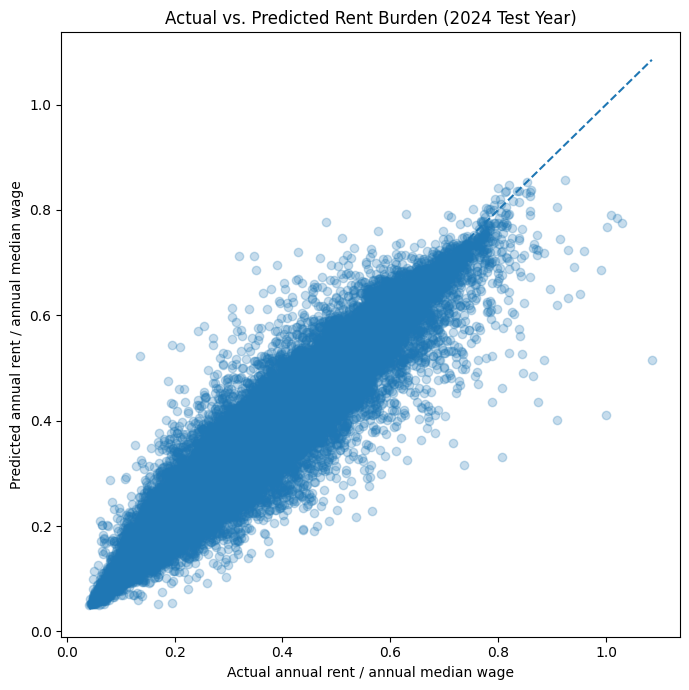

In [32]:
plt.figure(figsize=(7, 7))
plt.scatter(test_predictions[target_name], test_predictions["model_prediction"], alpha=0.25)
plt.plot(
    [
        test_predictions[target_name].min(),
        test_predictions[target_name].max(),
    ],
    [
        test_predictions[target_name].min(),
        test_predictions[target_name].max(),
    ],
    linestyle="--",
)
plt.title(f"Actual vs. Predicted Rent Burden ({test_year} Test Year)")
plt.xlabel("Actual annual rent / annual median wage")
plt.ylabel("Predicted annual rent / annual median wage")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_actual_vs_predicted_test.png", dpi=150)
plt.show()

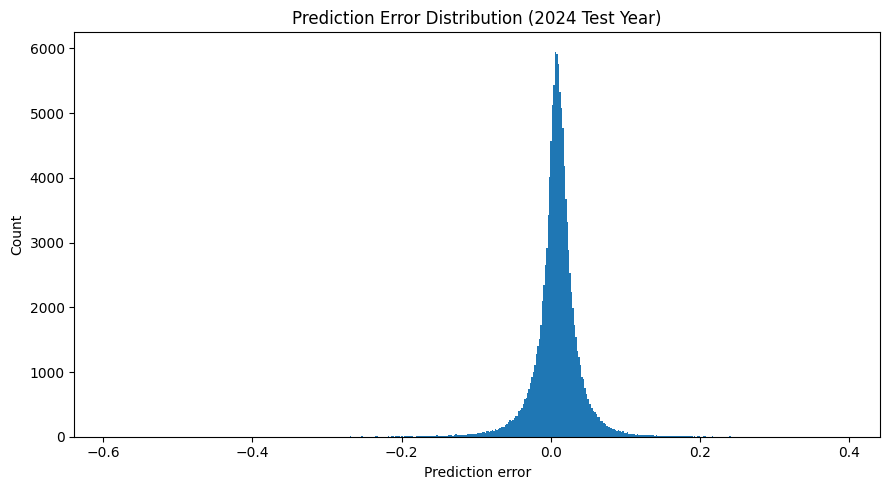

In [35]:
plt.figure(figsize=(9, 5))
plt.hist(test_predictions["model_error"], bins=500)
plt.title(f"Prediction Error Distribution ({test_year} Test Year)")
plt.xlabel("Prediction error")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_test_residual_distribution.png", dpi=150)
plt.show()

## 15. Random Forest Feature Importance

Feature importance is only computed for the Random Forest model. It is useful for explanation, but it should not be interpreted as causal.

Saved feature importance: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/modeling/random_forest_feature_importance.csv


,feature,importance
0,rent_to_median_wage_ratio_lag1,0.752808
1,median_wage_to_rent_ratio_lag1,0.223283
2,wage_annual_mean_lag1,0.006559
3,annual_rent_lag1,0.004072
4,wage_annual_median_lag1,0.002669
5,jobs_1000_lag1,0.001763
6,wage_growth_lag1,0.001739
7,loc_quotient_lag1,0.001215
8,median_household_income_lag1,0.001138
9,population_lag1,0.001035


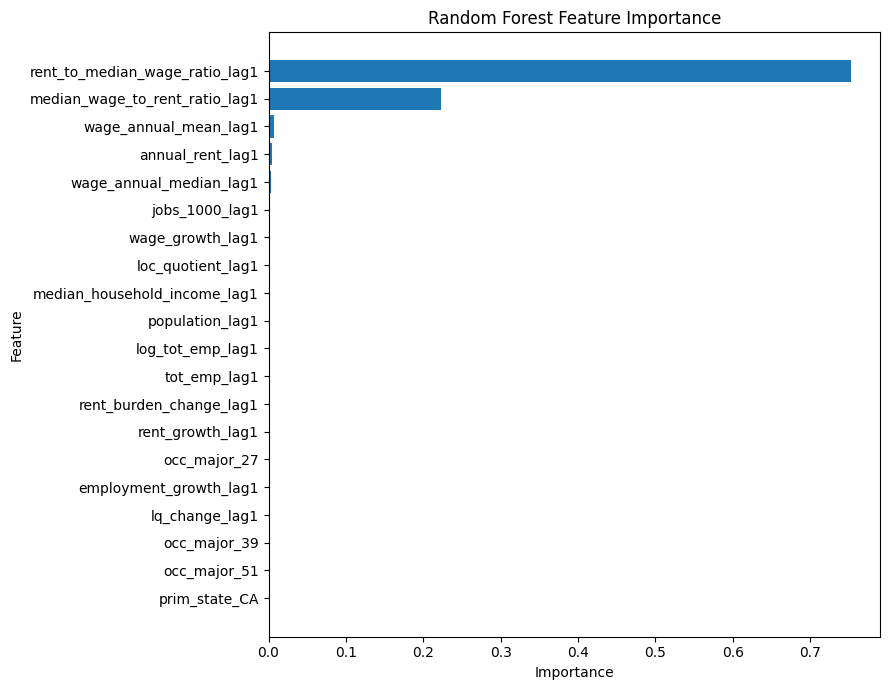

In [36]:
if "Random Forest" in fitted_models:
    rf_pipeline = fitted_models["Random Forest"]
    rf_model = rf_pipeline.named_steps["model"]

    if hasattr(rf_model, "feature_importances_"):
        rf_feature_names = get_pipeline_feature_names(
            rf_pipeline,
            numeric_features=numeric_features,
            categorical_features=categorical_features,
        )

        rf_importance = (
            pd.DataFrame({
                "feature": rf_feature_names,
                "importance": rf_model.feature_importances_,
            })
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )

        rf_importance_path = MODELING_DIR / "random_forest_feature_importance.csv"
        rf_importance.to_csv(rf_importance_path, index=False)

        print(f"Saved feature importance: {rf_importance_path}")
        display(rf_importance.head(25))

        top_imp = rf_importance.head(20).iloc[::-1]

        plt.figure(figsize=(9, 7))
        plt.barh(top_imp["feature"], top_imp["importance"])
        plt.title("Random Forest Feature Importance")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.savefig(FIG_DIR / "04_random_forest_feature_importance.png", dpi=150)
        plt.show()

## 16. Predict Next-Year Rent Burden for Latest Available Rows

This creates a dashboard-ready prediction table for the year after the latest observed year.

For example, if the processed dataset ends in 2024, this predicts 2025 rent burden using 2024 values as lag-1 features and 2023 values as lag-2 features.

In [37]:
future_base = panel.loc[panel["year"] == latest_year].copy()

future_pred = future_base[
    [
        "year",
        "cbsa_code",
        "bls_msa_name",
        "acs_area_name",
        "prim_state",
        "occ_code",
        "occ_title",
        "wage_annual_median",
        "annual_rent",
        "rent_to_median_wage_ratio",
        "median_wage_to_rent_ratio",
        "tot_emp",
        "jobs_1000",
        "loc_quotient",
        "occ_major",
    ]
].copy()

future_pred["prediction_year"] = latest_year + 1

for col in lag_source_cols:
    if col in future_base.columns:
        future_pred[f"{col}_lag1"] = future_base[col]
        future_pred[f"{col}_lag2"] = future_base.get(f"{col}_lag1")

future_pred["rent_burden_change_lag1"] = (
    future_pred["rent_to_median_wage_ratio_lag1"]
    - future_pred["rent_to_median_wage_ratio_lag2"]
)

future_pred["wage_growth_lag1"] = safe_divide(
    future_pred["wage_annual_median_lag1"],
    future_pred["wage_annual_median_lag2"],
) - 1

future_pred["rent_growth_lag1"] = safe_divide(
    future_pred["annual_rent_lag1"],
    future_pred["annual_rent_lag2"],
) - 1

future_pred["employment_growth_lag1"] = safe_divide(
    future_pred["tot_emp_lag1"],
    future_pred["tot_emp_lag2"],
) - 1

future_pred["lq_change_lag1"] = (
    future_pred["loc_quotient_lag1"]
    - future_pred["loc_quotient_lag2"]
)

future_pred = future_pred.replace([np.inf, -np.inf], np.nan)

future_model_input = future_pred[feature_cols]

future_pred["predicted_next_year_rent_to_median_wage_ratio"] = final_model.predict(
    future_model_input
)

future_pred["predicted_next_year_median_wage_to_rent_ratio"] = safe_divide(
    pd.Series(1.0, index=future_pred.index),
    future_pred["predicted_next_year_rent_to_median_wage_ratio"],
)

future_pred["predicted_change_in_rent_burden"] = (
    future_pred["predicted_next_year_rent_to_median_wage_ratio"]
    - future_pred["rent_to_median_wage_ratio"]
)

future_pred["predicted_improving_affordability"] = (
    future_pred["predicted_change_in_rent_burden"] < 0
)

future_output_cols = [
    "prediction_year",
    "year",
    "cbsa_code",
    "bls_msa_name",
    "acs_area_name",
    "prim_state",
    "occ_code",
    "occ_title",
    "wage_annual_median",
    "annual_rent",
    "rent_to_median_wage_ratio",
    "median_wage_to_rent_ratio",
    "tot_emp",
    "jobs_1000",
    "loc_quotient",
    "predicted_next_year_rent_to_median_wage_ratio",
    "predicted_next_year_median_wage_to_rent_ratio",
    "predicted_change_in_rent_burden",
    "predicted_improving_affordability",
]

future_pred[future_output_cols].to_csv(FUTURE_PREDICTIONS_CSV_PATH, index=False)

print_shape("Next-year prediction table", future_pred[future_output_cols])
print(f"Saved: {FUTURE_PREDICTIONS_CSV_PATH}")

display(
    future_pred[future_output_cols]
    .sort_values("predicted_change_in_rent_burden")
    .head(15)
)

Next-year prediction table: 141,164 rows × 19 columns
Saved: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/processed/career_city_next_year_predictions_latest.csv


,prediction_year,year,cbsa_code,bls_msa_name,acs_area_name,prim_state,occ_code,occ_title,wage_annual_median,annual_rent,rent_to_median_wage_ratio,median_wage_to_rent_ratio,tot_emp,jobs_1000,loc_quotient,predicted_next_year_rent_to_median_wage_ratio,predicted_next_year_median_wage_to_rent_ratio,predicted_change_in_rent_burden,predicted_improving_affordability
407867,2025,2024,34980,"Nashville-Davidson--Murfreesboro--Franklin, TN","Nashville-Davidson--Murfreesboro--Franklin, TN...",TN,39-6011,Baggage Porters and Bellhops,16900.0,18336.0,1.084970,0.921684,340.0,0.310,1.53,0.724869,1.379560,-0.360101,True
103384,2025,2024,16700,"Charleston-North Charleston, SC","Charleston-North Charleston, SC Metro Area",SC,25-9044,"Teaching Assistants, Postsecondary",19250.0,19260.0,1.000519,0.999481,160.0,0.421,0.42,0.694950,1.438952,-0.305569,True
263333,2025,2024,26420,"Houston-Pasadena-The Woodlands, TX","Houston-Pasadena-The Woodlands, TX Metro Area",TX,39-3093,"Locker Room, Coatroom, and Dressing Room Atten...",17880.0,17160.0,0.959732,1.041958,NaN,NaN,NaN,0.686276,1.457139,-0.273455,True
103891,2025,2024,16700,"Charleston-North Charleston, SC","Charleston-North Charleston, SC Metro Area",SC,35-3011,Bartenders,18710.0,19260.0,1.029396,0.971443,3440.0,8.859,1.83,0.772392,1.294679,-0.257004,True
104985,2025,2024,16740,"Charlotte-Concord-Gastonia, NC-SC","Charlotte-Concord-Gastonia, NC-SC Metro Area",NC,11-1031,Legislators,18570.0,17676.0,0.951858,1.050577,40.0,0.028,0.16,0.698975,1.430667,-0.252883,True
103901,2025,2024,16700,"Charleston-North Charleston, SC","Charleston-North Charleston, SC Metro Area",SC,35-3031,Waiters and Waitresses,18890.0,19260.0,1.019587,0.980789,9100.0,23.448,1.57,0.770160,1.298431,-0.249427,True
257128,2025,2024,25940,"Hilton Head Island-Bluffton-Port Royal, SC","Hilton Head Island-Bluffton-Port Royal, SC Met...",SC,35-3011,Bartenders,18830.0,18876.0,1.002443,0.997563,700.0,8.533,1.76,0.757366,1.320366,-0.245077,True
33304,2025,2024,12060,"Atlanta-Sandy Springs-Roswell, GA","Atlanta-Sandy Springs-Roswell, GA Metro Area",GA,35-3031,Waiters and Waitresses,20270.0,20064.0,0.989837,1.010267,43170.0,15.031,1.01,0.747648,1.337528,-0.242189,True
257138,2025,2024,25940,"Hilton Head Island-Bluffton-Port Royal, SC","Hilton Head Island-Bluffton-Port Royal, SC Met...",SC,35-3031,Waiters and Waitresses,18700.0,18876.0,1.009412,0.990676,3330.0,40.714,2.73,0.771404,1.296337,-0.238008,True
550353,2025,2024,42340,"Savannah, GA","Savannah, GA Metro Area",GA,11-1031,Legislators,19180.0,17448.0,0.909698,1.099266,30.0,0.170,0.99,0.676837,1.477461,-0.232861,True


## 17. Combined Dashboard Modeling Output

This combines the latest-year ranking score, metro cluster labels, and next-year prediction features into one dashboard-ready table.

In [38]:
dashboard_output = score_df.merge(
    metro_profile[
        [
            "cbsa_code",
            "metro_cluster",
            "pca_1",
            "pca_2",
            "mean_rent_burden",
            "mean_occ_wage",
            "share_high_lq",
        ]
    ],
    on="cbsa_code",
    how="left",
)

dashboard_output = dashboard_output.merge(
    future_pred[
        [
            "cbsa_code",
            "occ_code",
            "prediction_year",
            "predicted_next_year_rent_to_median_wage_ratio",
            "predicted_next_year_median_wage_to_rent_ratio",
            "predicted_change_in_rent_burden",
            "predicted_improving_affordability",
        ]
    ],
    on=["cbsa_code", "occ_code"],
    how="left",
)

dashboard_output.to_csv(FINAL_DASHBOARD_OUTPUT_CSV_PATH, index=False)

print_shape("Combined dashboard modeling output", dashboard_output)
print(f"Saved: {FINAL_DASHBOARD_OUTPUT_CSV_PATH}")

display(dashboard_output.head(15))

Combined dashboard modeling output: 138,812 rows × 34 columns
Saved: /Users/omarelnesr/Desktop/Classes/CIS 2450/Final Project/data/processed/dashboard_modeling_output_latest.csv


,year,cbsa_code,bls_msa_name,acs_area_name,prim_state,occ_code,occ_title,wage_annual_median,annual_rent,rent_to_median_wage_ratio,...,pca_1,pca_2,mean_rent_burden,mean_occ_wage,share_high_lq,prediction_year,predicted_next_year_rent_to_median_wage_ratio,predicted_next_year_median_wage_to_rent_ratio,predicted_change_in_rent_burden,predicted_improving_affordability
0,2024,44100,"Springfield, IL","Springfield, IL Metro Area",IL,13-2011,Accountants and Auditors,83970.0,11748,0.139907,...,0.333290,-1.356750,0.222672,61977.544127,0.309148,2025,0.160813,6.218416,0.020906,False
1,2024,37620,"Parkersburg-Vienna, WV","Parkersburg-Vienna, WV Metro Area",WV,13-2011,Accountants and Auditors,95640.0,9816,0.102635,...,-4.175968,0.318035,0.227272,54304.176471,0.434524,2025,0.125366,7.976672,0.022731,False
2,2024,33220,"Midland, MI","Midland, MI Metro Area",MI,13-2011,Accountants and Auditors,86390.0,12192,0.141127,...,0.283506,-0.198767,0.227575,66366.569767,0.369318,2025,0.148359,6.740406,0.007232,False
3,2024,43620,"Sioux Falls, SD-MN","Sioux Falls, SD-MN Metro Area",SD,13-2011,Accountants and Auditors,79650.0,12264,0.153974,...,-0.703367,-0.093466,0.241309,59629.535025,0.41519,2025,0.163071,6.132296,0.009097,False
4,2024,15380,"Buffalo-Cheektowaga, NY","Buffalo-Cheektowaga, NY Metro Area",NY,13-2011,Accountants and Auditors,80240.0,12684,0.158076,...,2.242975,-2.535410,0.218456,68812.058639,0.280277,2025,0.165857,6.029290,0.007781,False
5,2024,17410,"Cleveland, OH","Cleveland, OH Metro Area",OH,13-2011,Accountants and Auditors,78360.0,12600,0.160796,...,2.754831,-3.179537,0.235797,63167.935360,0.25938,2025,0.171374,5.835191,0.010578,False
6,2024,19340,"Davenport-Moline-Rock Island, IA-IL","Davenport-Moline-Rock Island, IA-IL Metro Area",IA,13-2011,Accountants and Auditors,77280.0,11292,0.146118,...,0.221212,-2.726141,0.218232,60914.624824,0.262181,2025,0.154756,6.461776,0.008638,False
7,2024,46140,"Tulsa, OK","Tulsa, OK Metro Area",OK,13-2011,Accountants and Auditors,78500.0,12936,0.164790,...,0.581267,-1.730416,0.263439,58689.759231,0.277014,2025,0.173546,5.762171,0.008756,False
8,2024,45060,"Syracuse, NY","Syracuse, NY Metro Area",NY,13-2011,Accountants and Auditors,79790.0,12924,0.161975,...,1.304816,-2.200433,0.224117,67576.852510,0.309804,2025,0.168661,5.929058,0.006686,False
9,2024,46540,"Utica-Rome, NY","Utica-Rome, NY Metro Area",NY,13-2011,Accountants and Auditors,76730.0,11100,0.144663,...,-1.082579,-2.298505,0.204333,63555.088136,0.33241,2025,0.153424,6.517895,0.008761,False


## 18. Final Artifact Summary

In [39]:
artifact_summary = pd.DataFrame(
    [
        {
            "artifact": "latest occupation-metro dashboard score",
            "path": str(LATEST_SCORE_CSV_PATH),
        },
        {
            "artifact": "clustered metro profiles",
            "path": str(METRO_PROFILE_CSV_PATH),
        },
        {
            "artifact": "nearest-neighbor metro table",
            "path": str(NEAREST_METROS_CSV_PATH),
        },
        {
            "artifact": "regression metrics",
            "path": str(REGRESSION_METRICS_CSV_PATH),
        },
        {
            "artifact": "test predictions",
            "path": str(REGRESSION_TEST_PREDICTIONS_CSV_PATH),
        },
        {
            "artifact": "next-year predictions",
            "path": str(FUTURE_PREDICTIONS_CSV_PATH),
        },
        {
            "artifact": "combined dashboard modeling output",
            "path": str(FINAL_DASHBOARD_OUTPUT_CSV_PATH),
        },
        {
            "artifact": "model directory",
            "path": str(MODEL_DIR),
        },
        {
            "artifact": "modeling figures directory",
            "path": str(FIG_DIR),
        },
    ]
)

display(artifact_summary)

,artifact,path
0,latest occupation-metro dashboard score,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
1,clustered metro profiles,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
2,nearest-neighbor metro table,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
3,regression metrics,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
4,test predictions,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
5,next-year predictions,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
6,combined dashboard modeling output,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
7,model directory,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...
8,modeling figures directory,/Users/omarelnesr/Desktop/Classes/CIS 2450/Fin...


## 19. Notes for Interpretation

Important interpretation notes:

1. The dashboard ranking score is a transparent weighted score, not a causal or predictive model.
2. Lower rent burden means better affordability.
3. K-Means clusters are exploratory metro segments, not definitive city categories.
4. Nearest-neighbor similarity is based on standardized metro-level features.
5. Regression models are evaluated with time-based splits to avoid random-split leakage.
6. Forecasts should be presented as short-term signals, not precise predictions.
7. Small occupation–metro labor markets should be treated carefully, especially when `tot_emp < 100` or location quotient is low.